# Five ML Algorithms from Scratch

Linear regression · Logistic regression · PCA · Neural network with backpropagation · SVM (dual form)

Everything here is written with plain NumPy. scikit-learn is used for two things only:
loading the datasets, and checking that my answers are right.

Each section is the same four steps — the idea, the code, the check against scikit-learn,
and a plot.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sklearn.linear_model as sk_linear
import sklearn.decomposition as sk_decomp
import sklearn.neural_network as sk_nn
import sklearn.svm as sk_svm

SEED = 0

# plot colours (checked to stay distinguishable for colourblind readers)
BLUE, ORANGE = "#007096", "#c2703a"
INK, GREY = "#1b2528", "#5a6b70"
CMAP2 = LinearSegmentedColormap.from_list("twoclass", [BLUE, "#ffffff", ORANGE])

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9.5, "figure.facecolor": "white",
    "axes.edgecolor": GREY, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": GREY, "ytick.color": GREY, "axes.titlesize": 10,
    "axes.titlelocation": "left", "axes.spines.top": False,
    "axes.spines.right": False, "legend.frameon": False, "lines.linewidth": 2,
})

# every check gets appended here, and printed as one table at the end
RESULTS = []

def check(name, mine, reference, ok):
    RESULTS.append((name, mine, reference, ok))
    print(f"[{'PASS' if ok else 'FAIL'}] {name:<44} {mine:>14}  vs  {reference}")

In [2]:
# Regression data: diabetes
X_reg, y_reg = datasets.load_diabetes(return_X_y=True)
X_reg = StandardScaler().fit_transform(X_reg)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=SEED)

# Binary classification data: breast cancer
X_bin, y_bin = datasets.load_breast_cancer(return_X_y=True)
X_bin = StandardScaler().fit_transform(X_bin)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bin, y_bin, test_size=0.25, random_state=SEED, stratify=y_bin)

# Image data: 8x8 handwritten digits
X_digits, y_digits = datasets.load_digits(return_X_y=True)
X_dig = StandardScaler().fit_transform(X_digits)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_dig, y_digits, test_size=0.25, random_state=SEED, stratify=y_digits)

# Small 2-D data, only for drawing decision boundaries
X_moons, y_moons = datasets.make_moons(n_samples=300, noise=0.22, random_state=SEED)

print("diabetes     ", X_reg.shape)
print("breast cancer", X_bin.shape)
print("digits       ", X_dig.shape)
print("moons        ", X_moons.shape)

diabetes      (442, 10)
breast cancer (569, 30)
digits        (1797, 64)
moons         (300, 2)


---

# 1. Linear regression

Fit a straight line by minimising the squared error:

$$J(w) = \lVert y - Xw \rVert^2 + \alpha \lVert w \rVert^2$$

Setting the derivative to zero gives one equation we can solve directly:

$$(X^\top X + \alpha I)\,w = X^\top y$$

`alpha = 0` is ordinary least squares. `alpha > 0` is ridge, which shrinks the
coefficients toward zero.

The intercept is handled by adding a column of ones to `X`, and that column is left out
of the penalty.

I also fit the same thing with gradient descent, to show it lands on the same answer.

In [3]:
def add_ones(X):
    # a column of 1s lets the intercept ride along as w[0]
    return np.hstack([np.ones((len(X), 1)), X])


def fit_linear(X, y, alpha=0.0):
    X = add_ones(X)
    penalty = alpha * np.eye(X.shape[1])
    penalty[0, 0] = 0          # don't penalise the intercept
    w = np.linalg.solve(X.T @ X + penalty, X.T @ y)
    return w


def fit_linear_gd(X, y, lr=0.05, n_steps=2000):
    X = add_ones(X)
    w = np.zeros(X.shape[1])
    losses = []
    for _ in range(n_steps):
        error = X @ w - y
        gradient = 2 * X.T @ error / len(y)
        w = w - lr * gradient
        losses.append(error @ error)
    return w, losses


def predict_linear(X, w):
    return add_ones(X) @ w


def r2_score(y, y_pred):
    return 1 - ((y - y_pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()

In [4]:
w_ols = fit_linear(Xr_train, yr_train)
w_ridge = fit_linear(Xr_train, yr_train, alpha=2.5)
w_gd, gd_losses = fit_linear_gd(Xr_train, yr_train, lr=0.05, n_steps=20000)

ref_ols = sk_linear.LinearRegression().fit(Xr_train, yr_train)
ref_ridge = sk_linear.Ridge(alpha=2.5).fit(Xr_train, yr_train)

diff_ols = np.abs(w_ols[1:] - ref_ols.coef_).max()
diff_ridge = np.abs(w_ridge[1:] - ref_ridge.coef_).max()
diff_gd = np.abs(w_gd - w_ols).max()
my_r2 = r2_score(yr_test, predict_linear(Xr_test, w_ols))

check("linear: coefficients vs sklearn", f"{diff_ols:.2e}", "0 (want <1e-8)", diff_ols < 1e-8)
check("ridge: coefficients vs sklearn", f"{diff_ridge:.2e}", "0 (want <1e-8)", diff_ridge < 1e-8)
check("linear: gradient descent vs direct solve", f"{diff_gd:.2e}", "0 (want <1e-3)", diff_gd < 1e-3)
check("linear: test R^2", f"{my_r2:.6f}", f"{ref_ols.score(Xr_test, yr_test):.6f}",
      abs(my_r2 - ref_ols.score(Xr_test, yr_test)) < 1e-10)

[PASS] linear: coefficients vs sklearn                    1.38e-12  vs  0 (want <1e-8)
[PASS] ridge: coefficients vs sklearn                     5.33e-13  vs  0 (want <1e-8)
[PASS] linear: gradient descent vs direct solve           1.91e-07  vs  0 (want <1e-3)
[PASS] linear: test R^2                                   0.359409  vs  0.359409


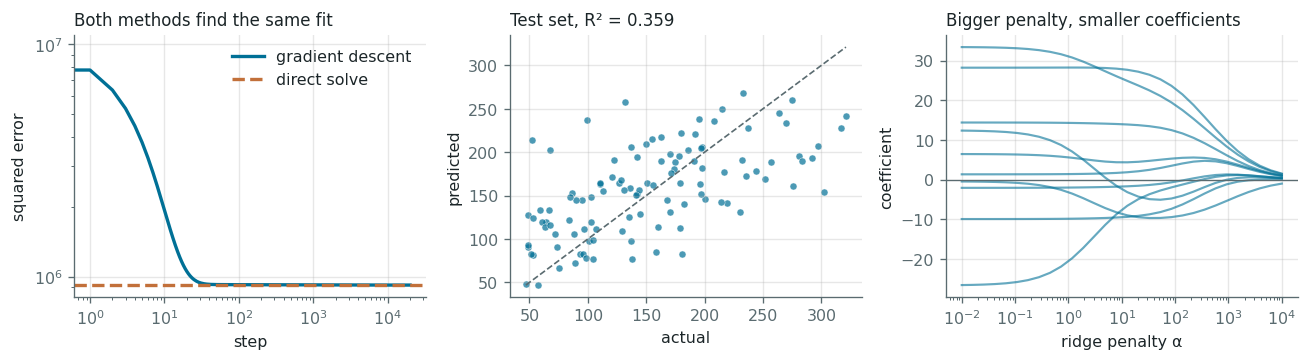

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))

# gradient descent walking down to the answer we already solved for
best_loss = ((yr_train - predict_linear(Xr_train, w_ols)) ** 2).sum()
axes[0].plot(gd_losses, color=BLUE, label="gradient descent")
axes[0].axhline(best_loss, color=ORANGE, ls="--", label="direct solve")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("step"); axes[0].set_ylabel("squared error")
axes[0].set_title("Both methods find the same fit")
axes[0].legend()

# predictions vs truth
pred = predict_linear(Xr_test, w_ols)
axes[1].scatter(yr_test, pred, s=18, color=BLUE, alpha=0.7, edgecolor="white", lw=0.4)
line = [min(yr_test.min(), pred.min()), max(yr_test.max(), pred.max())]
axes[1].plot(line, line, color=GREY, ls="--", lw=1)
axes[1].set_xlabel("actual"); axes[1].set_ylabel("predicted")
axes[1].set_title(f"Test set, R² = {my_r2:.3f}")

# what the ridge penalty does
alphas = np.logspace(-2, 4, 30)
paths = np.array([fit_linear(Xr_train, yr_train, alpha=a)[1:] for a in alphas])
for j in range(paths.shape[1]):
    axes[2].plot(alphas, paths[:, j], color=BLUE, alpha=0.6, lw=1.3)
axes[2].axhline(0, color=GREY, lw=0.8)
axes[2].set_xscale("log")
axes[2].set_xlabel("ridge penalty α"); axes[2].set_ylabel("coefficient")
axes[2].set_title("Bigger penalty, smaller coefficients")

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

# 2. Logistic regression

Same linear score $z = Xw$, but squashed into a probability:

$$p = \sigma(z) = \frac{1}{1 + e^{-z}}$$

and trained on the log-loss. The gradient works out to

$$\nabla J = X^\top (p - y) + \lambda w$$

which is the same shape as linear regression's gradient — "X transpose times the error".
That is worth remembering; it is not a coincidence.

There is no direct solve this time, because `p` depends on `w` non-linearly. So two
options:

- **gradient descent** — take small steps downhill, many of them
- **Newton's method** — also use the second derivative, which needs a matrix solve per
  step but gets there in about ten steps

Newton's method is the one that matches scikit-learn's coefficients, so that's the one
I check.

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


def log_loss(X, y, w, lam):
    z = X @ w
    # np.logaddexp(0, z) is log(1 + e^z) without overflowing
    return np.sum(np.logaddexp(0, z) - y * z) + 0.5 * lam * np.sum(w[1:] ** 2)


def fit_logistic_gd(X, y, lr=0.001, n_steps=4000, lam=1.0):
    X = add_ones(X)
    w = np.zeros(X.shape[1])
    losses = []
    for _ in range(n_steps):
        p = sigmoid(X @ w)
        gradient = X.T @ (p - y) + lam * np.r_[0, w[1:]]     # intercept not penalised
        w = w - lr * gradient
        losses.append(log_loss(X, y, w, lam))
    return w, losses


def fit_logistic_newton(X, y, n_steps=15, lam=1.0):
    X = add_ones(X)
    w = np.zeros(X.shape[1])
    penalty = lam * np.eye(X.shape[1])
    penalty[0, 0] = 0
    losses = []
    for _ in range(n_steps):
        p = sigmoid(X @ w)
        gradient = X.T @ (p - y) + penalty @ w
        # second derivative of the log-loss
        hessian = (X * (p * (1 - p))[:, None]).T @ X + penalty
        w = w - np.linalg.solve(hessian, gradient)
        losses.append(log_loss(X, y, w, lam))
    return w, losses


def predict_logistic(X, w):
    return (sigmoid(add_ones(X) @ w) > 0.5).astype(int)

In [7]:
w_newton, newton_losses = fit_logistic_newton(Xb_train, yb_train, lam=1.0)
w_gd_log, gd_log_losses = fit_logistic_gd(Xb_train, yb_train, lam=1.0)

ref_log = sk_linear.LogisticRegression(C=1.0, max_iter=10000, tol=1e-12)
ref_log.fit(Xb_train, yb_train)

diff_coef = np.abs(w_newton[1:] - ref_log.coef_.ravel()).max()
my_acc = (predict_logistic(Xb_test, w_newton) == yb_test).mean()
ref_acc = ref_log.score(Xb_test, yb_test)
falling = np.all(np.diff(gd_log_losses) <= 1e-8)

check("logistic: coefficients vs sklearn", f"{diff_coef:.2e}", "0 (want <1e-4)", diff_coef < 1e-4)
check("logistic: test accuracy", f"{my_acc:.6f}", f"{ref_acc:.6f}", my_acc == ref_acc)
check("logistic: loss always goes down", str(bool(falling)), "True", bool(falling))

[PASS] logistic: coefficients vs sklearn                  7.65e-07  vs  0 (want <1e-4)
[PASS] logistic: test accuracy                            0.958042  vs  0.958042
[PASS] logistic: loss always goes down                        True  vs  True


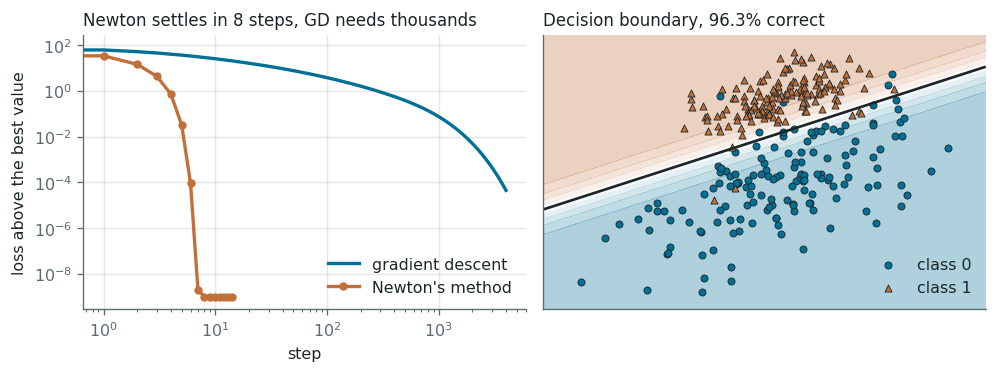

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2))

# how many steps each method needs
lowest = min(min(newton_losses), min(gd_log_losses))
axes[0].plot(np.array(gd_log_losses) - lowest + 1e-9, color=BLUE, label="gradient descent")
axes[0].plot(np.array(newton_losses) - lowest + 1e-9, color=ORANGE, marker="o", ms=4,
             label="Newton's method")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss above the best value")
# report where Newton actually converged, not how many times the loop ran
settled = next(i for i, loss in enumerate(newton_losses, 1) if loss - lowest < 1e-9)
axes[0].set_title(f"Newton settles in {settled} steps, GD needs thousands")
axes[0].legend(); axes[0].grid(alpha=0.3)

# the fitted boundary, in 2-D so we can see it
X2, y2 = datasets.make_classification(n_samples=300, n_features=2, n_redundant=0,
                                      n_informative=2, n_clusters_per_class=1,
                                      class_sep=1.3, random_state=SEED)
w2, _ = fit_logistic_newton(X2, y2)
xx, yy = np.meshgrid(np.linspace(X2[:, 0].min() - .5, X2[:, 0].max() + .5, 200),
                     np.linspace(X2[:, 1].min() - .5, X2[:, 1].max() + .5, 200))
probs = sigmoid(add_ones(np.c_[xx.ravel(), yy.ravel()]) @ w2).reshape(xx.shape)
axes[1].contourf(xx, yy, probs, levels=np.linspace(0, 1, 11), cmap=CMAP2, alpha=0.35)
axes[1].contour(xx, yy, probs, levels=[0.5], colors=[INK], linewidths=1.6)
for label, colour, marker in [(0, BLUE, "o"), (1, ORANGE, "^")]:
    keep = y2 == label
    axes[1].scatter(X2[keep, 0], X2[keep, 1], s=18, color=colour, marker=marker,
                    edgecolor=INK, lw=0.5, label=f"class {label}")
axes[1].set_xticks([]); axes[1].set_yticks([])
accuracy_2d = (predict_logistic(X2, w2) == y2).mean()
axes[1].set_title(f"Decision boundary, {accuracy_2d:.1%} correct")
axes[1].legend(loc="lower right")

plt.tight_layout(); plt.show()

---

# 3. PCA

Find the directions the data varies along most, and describe each point by only a few of
them.

Centre the data, then take the eigenvectors of the covariance matrix
$C = \frac{1}{n-1} X_c^\top X_c$. The eigenvector with the biggest eigenvalue is the
direction of most variance, and **the eigenvalue is that variance**.

In practice I use the SVD, $X_c = U S V^\top$, because the components come straight out
of $V$ and it never forms $C$ (squaring a matrix squares its numerical error). The
eigenvalue version is two lines, so it is here too, and both are checked to agree.

Components are only defined up to a sign flip, so I pin the sign down — otherwise two
runs disagree for no reason.

In [9]:
def fit_pca(X, k):
    mean = X.mean(axis=0)
    X_centred = X - mean
    U, S, Vt = np.linalg.svd(X_centred, full_matrices=False)
    variances = S ** 2 / (len(X) - 1)
    components = Vt[:k]

    for i in range(k):                      # fix the arbitrary sign
        biggest = np.argmax(np.abs(components[i]))
        if components[i, biggest] < 0:
            components[i] = -components[i]

    return mean, components, variances[:k], variances.sum()


def fit_pca_eig(X, k):
    # same thing the textbook way: eigenvectors of the covariance matrix
    mean = X.mean(axis=0)
    X_centred = X - mean
    covariance = X_centred.T @ X_centred / (len(X) - 1)
    values, vectors = np.linalg.eigh(covariance)
    order = np.argsort(values)[::-1]        # eigh returns them smallest first
    return mean, vectors[:, order].T[:k], values[order][:k]


def pca_transform(X, mean, components):
    return (X - mean) @ components.T


def pca_reconstruct(Z, mean, components):
    return Z @ components + mean

In [10]:
mean, comps, variances, total_variance = fit_pca(X_digits, k=20)
ratios = variances / total_variance

ref_pca = sk_decomp.PCA(n_components=20, svd_solver="full").fit(X_digits)
_, comps_eig, _ = fit_pca_eig(X_digits, k=20)

diff_ratio = np.abs(ratios - ref_pca.explained_variance_ratio_).max()
diff_comp = np.abs(np.abs(comps) - np.abs(ref_pca.components_)).max()
diff_method = np.abs(np.abs(comps) - np.abs(comps_eig)).max()
orthogonal = np.abs(comps @ comps.T - np.eye(20)).max()

check("pca: variance ratios vs sklearn", f"{diff_ratio:.2e}", "0 (want <1e-10)", diff_ratio < 1e-10)
check("pca: components vs sklearn", f"{diff_comp:.2e}", "0 (want <1e-8)", diff_comp < 1e-8)
check("pca: svd version vs eigenvalue version", f"{diff_method:.2e}", "0 (want <1e-6)", diff_method < 1e-6)
check("pca: components are orthonormal", f"{orthogonal:.2e}", "0 (want <1e-10)", orthogonal < 1e-10)

print(f"\n20 of the 64 directions hold {ratios.sum():.1%} of the variance")

[PASS] pca: variance ratios vs sklearn                    0.00e+00  vs  0 (want <1e-10)
[PASS] pca: components vs sklearn                         0.00e+00  vs  0 (want <1e-8)
[PASS] pca: svd version vs eigenvalue version             1.46e-14  vs  0 (want <1e-6)
[PASS] pca: components are orthonormal                    2.22e-15  vs  0 (want <1e-10)

20 of the 64 directions hold 89.4% of the variance


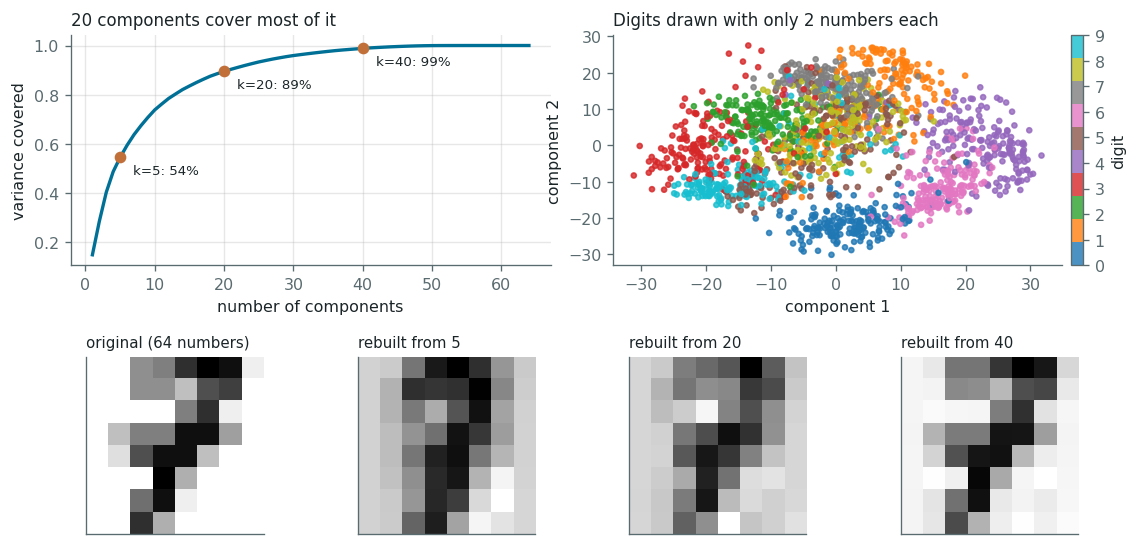

In [11]:
fig = plt.figure(figsize=(11, 5.4))
grid_spec = fig.add_gridspec(2, 4, height_ratios=[1.3, 1], hspace=0.45, wspace=0.3)

# how much variance the first k directions cover
_, _, all_variances, total = fit_pca(X_digits, k=64)
cumulative = np.cumsum(all_variances / total)
ax = fig.add_subplot(grid_spec[0, :2])
ax.plot(range(1, 65), cumulative, color=BLUE)
for k in (5, 20, 40):
    ax.plot(k, cumulative[k - 1], "o", color=ORANGE)
    ax.annotate(f"k={k}: {cumulative[k-1]:.0%}", (k, cumulative[k - 1]),
                textcoords="offset points", xytext=(8, -10), fontsize=8)
ax.set_xlabel("number of components"); ax.set_ylabel("variance covered")
ax.set_title("20 components cover most of it")
ax.grid(alpha=0.3)

# the digits squashed down to 2 dimensions
ax = fig.add_subplot(grid_spec[0, 2:])
mean2, comps2, _, _ = fit_pca(X_digits, k=2)
Z = pca_transform(X_digits, mean2, comps2)
dots = ax.scatter(Z[:, 0], Z[:, 1], c=y_digits, cmap="tab10", s=9, alpha=0.8)
ax.set_xlabel("component 1"); ax.set_ylabel("component 2")
ax.set_title("Digits drawn with only 2 numbers each")
fig.colorbar(dots, ax=ax, ticks=range(10), fraction=0.046, pad=0.02, label="digit")

# what a digit looks like after being squashed and rebuilt
one_digit = X_digits[7]
ax = fig.add_subplot(grid_spec[1, 0])
ax.imshow(one_digit.reshape(8, 8), cmap="gray_r")
ax.set_title("original (64 numbers)", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
for position, k in enumerate([5, 20, 40]):
    m, c, _, _ = fit_pca(X_digits, k=k)
    rebuilt = pca_reconstruct(pca_transform(one_digit[None], m, c), m, c)[0]
    ax = fig.add_subplot(grid_spec[1, position + 1])
    ax.imshow(rebuilt.reshape(8, 8), cmap="gray_r")
    ax.set_title(f"rebuilt from {k}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.show()

---

# 4. Neural network with backpropagation

One hidden layer, written out with four named arrays — `W1, b1, W2, b2` — rather than a
general list of layers. It is easier to follow, and one hidden layer is enough to show
what backpropagation does.

**Forward:**

$$h = \mathrm{ReLU}(XW_1 + b_1), \qquad p = \mathrm{softmax}(hW_2 + b_2)$$

**Backward.** The useful fact is that with softmax output and cross-entropy loss, the
messy derivative collapses to

$$\frac{\partial L}{\partial z_{\text{out}}} = \frac{p - y}{n}$$

Just the error, divided by the batch size. That is why those two are always used
together. Everything else is the chain rule from there.

Training is plain mini-batch gradient descent — no Adam, no momentum.

Since I derived the gradients by hand, they might be wrong. `gradient_check` nudges one
weight up and down and compares the change in loss to what the gradient predicted. If
they agree to about 8 decimal places, the derivation is right.

In [12]:
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)     # subtract the max so exp can't overflow
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def one_hot(y, n_classes):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1
    return Y


def init_network(n_inputs, n_hidden, n_outputs, seed=0):
    rng = np.random.default_rng(seed)
    # scale of sqrt(2/fan_in) keeps the signal from shrinking through ReLU
    W1 = rng.normal(0, np.sqrt(2 / n_inputs), (n_inputs, n_hidden))
    b1 = np.zeros(n_hidden)
    W2 = rng.normal(0, np.sqrt(2 / n_hidden), (n_hidden, n_outputs))
    b2 = np.zeros(n_outputs)
    return W1, b1, W2, b2


def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    h = np.maximum(z1, 0)                    # ReLU
    p = softmax(h @ W2 + b2)
    return z1, h, p


def backward(X, Y, z1, h, p, W2):
    n = len(X)
    d_out = (p - Y) / n                      # softmax + cross-entropy shortcut
    gW2 = h.T @ d_out
    gb2 = d_out.sum(axis=0)

    d_hidden = (d_out @ W2.T) * (z1 > 0)     # chain rule back through the ReLU
    gW1 = X.T @ d_hidden
    gb1 = d_hidden.sum(axis=0)
    return gW1, gb1, gW2, gb2


def cross_entropy(X, Y, W1, b1, W2, b2):
    _, _, p = forward(X, W1, b1, W2, b2)
    return -np.mean(np.sum(Y * np.log(np.clip(p, 1e-12, None)), axis=1))


def train_network(X, y, n_hidden=64, lr=0.5, epochs=100, batch_size=64, seed=0):
    n_classes = len(np.unique(y))
    Y = one_hot(y, n_classes)
    W1, b1, W2, b2 = init_network(X.shape[1], n_hidden, n_classes, seed)

    rng = np.random.default_rng(seed)
    losses = []
    for _ in range(epochs):
        order = rng.permutation(len(X))
        for start in range(0, len(X), batch_size):
            batch = order[start:start + batch_size]
            z1, h, p = forward(X[batch], W1, b1, W2, b2)
            gW1, gb1, gW2, gb2 = backward(X[batch], Y[batch], z1, h, p, W2)
            W1 -= lr * gW1
            b1 -= lr * gb1
            W2 -= lr * gW2
            b2 -= lr * gb2
        losses.append(cross_entropy(X, Y, W1, b1, W2, b2))
    return (W1, b1, W2, b2), losses


def predict_network(X, params):
    return np.argmax(forward(X, *params)[2], axis=1)

In [13]:
def gradient_check(step=1e-5, n_weights=40, seed=0):
    # small made-up problem so this runs instantly
    X, y = datasets.make_classification(n_samples=60, n_features=8, n_informative=6,
                                        n_classes=3, random_state=0)
    Y = one_hot(y, 3)
    W1, b1, W2, b2 = init_network(8, 16, 3, seed=0)

    z1, h, p = forward(X, W1, b1, W2, b2)
    gW1, _, _, _ = backward(X, Y, z1, h, p, W2)

    rng = np.random.default_rng(seed)
    worst = 0
    for _ in range(n_weights):
        i, j = rng.integers(W1.shape[0]), rng.integers(W1.shape[1])
        original = W1[i, j]

        W1[i, j] = original + step
        loss_up = cross_entropy(X, Y, W1, b1, W2, b2)
        W1[i, j] = original - step
        loss_down = cross_entropy(X, Y, W1, b1, W2, b2)
        W1[i, j] = original

        measured = (loss_up - loss_down) / (2 * step)   # slope by brute force
        predicted = gW1[i, j]                           # slope from my derivation
        worst = max(worst, abs(measured - predicted) / (abs(measured) + abs(predicted)))
    return worst


steps = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
errors = [gradient_check(step=s) for s in steps]
print("step size    error")
for s, e in zip(steps, errors):
    print(f"{s:>9.0e}    {e:.2e}")

best = min(errors)
check("network: my gradients vs measured slopes", f"{best:.2e}", "0 (want <1e-6)", best < 1e-6)

step size    error
    1e-03    3.89e-07
    1e-04    3.86e-09
    1e-05    1.13e-08
    1e-06    1.57e-07
    1e-07    1.30e-06
    1e-08    1.57e-05
[PASS] network: my gradients vs measured slopes           3.86e-09  vs  0 (want <1e-6)


In [14]:
params, nn_losses = train_network(Xd_train, yd_train, n_hidden=64, lr=0.5, epochs=100)
my_acc = (predict_network(Xd_test, params) == yd_test).mean()

ref_nn = sk_nn.MLPClassifier(hidden_layer_sizes=(64,), max_iter=600, random_state=SEED)
ref_nn.fit(Xd_train, yd_train)
ref_acc = ref_nn.score(Xd_test, yd_test)

check("network: digits test accuracy", f"{my_acc:.4f}", f"{ref_acc:.4f} (want within 0.05)",
      my_acc >= ref_acc - 0.05)

[PASS] network: digits test accuracy                        0.9778  vs  0.9733 (want within 0.05)


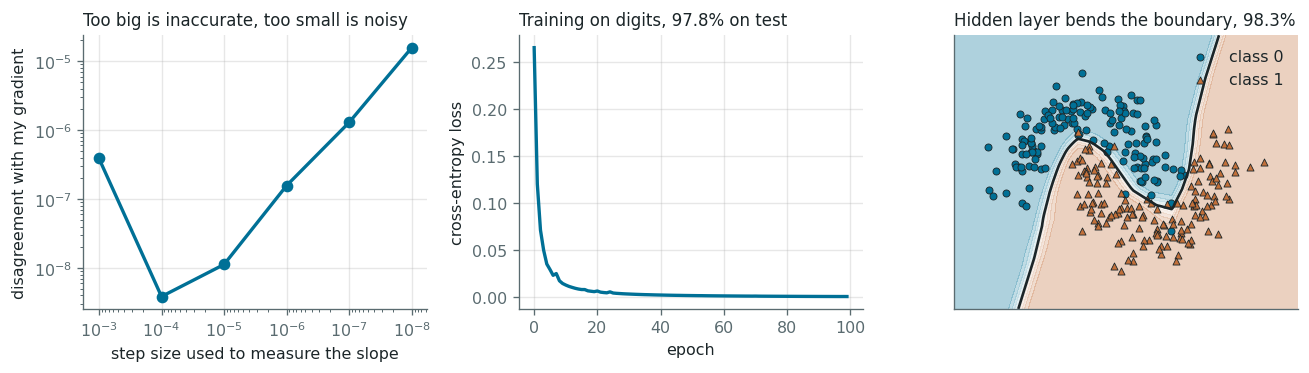

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

# the gradient check, and why the step size matters
axes[0].plot(steps, errors, color=BLUE, marker="o")
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].invert_xaxis()
axes[0].set_xlabel("step size used to measure the slope")
axes[0].set_ylabel("disagreement with my gradient")
axes[0].set_title("Too big is inaccurate, too small is noisy")
axes[0].grid(alpha=0.3)

# training curve
axes[1].plot(nn_losses, color=BLUE)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("cross-entropy loss")
axes[1].set_title(f"Training on digits, {my_acc:.1%} on test")
axes[1].grid(alpha=0.3)

# a curved boundary a straight line could never draw
moon_params, _ = train_network(X_moons, y_moons, n_hidden=32, lr=0.5, epochs=400)
xx, yy = np.meshgrid(np.linspace(X_moons[:, 0].min() - .5, X_moons[:, 0].max() + .5, 200),
                     np.linspace(X_moons[:, 1].min() - .5, X_moons[:, 1].max() + .5, 200))
probs = forward(np.c_[xx.ravel(), yy.ravel()], *moon_params)[2][:, 1].reshape(xx.shape)
axes[2].contourf(xx, yy, probs, levels=np.linspace(0, 1, 11), cmap=CMAP2, alpha=0.35)
axes[2].contour(xx, yy, probs, levels=[0.5], colors=[INK], linewidths=1.6)
for label, colour, marker in [(0, BLUE, "o"), (1, ORANGE, "^")]:
    keep = y_moons == label
    axes[2].scatter(X_moons[keep, 0], X_moons[keep, 1], s=18, color=colour, marker=marker,
                    edgecolor=INK, lw=0.5, label=f"class {label}")
axes[2].set_xticks([]); axes[2].set_yticks([])
moon_acc = (predict_network(X_moons, moon_params) == y_moons).mean()
axes[2].set_title(f"Hidden layer bends the boundary, {moon_acc:.1%}")
axes[2].legend(loc="upper right")

plt.tight_layout(); plt.show()

---

# 5. Support vector machine (dual form)

Find the boundary with the widest gap between the two classes. Written the usual way:

$$\min \; \tfrac{1}{2}\lVert w \rVert^2 + C\sum_i \xi_i
\quad\text{subject to}\quad y_i(w^\top x_i + b) \ge 1 - \xi_i$$

Rewriting it in terms of Lagrange multipliers $\alpha_i$ gives the **dual**:

$$\max_\alpha \; \sum_i \alpha_i - \tfrac{1}{2}\sum_i\sum_j \alpha_i\alpha_j y_i y_j K(x_i, x_j)
\quad\text{with}\quad 0 \le \alpha_i \le C, \quad \sum_i \alpha_i y_i = 0$$

Two things come out of this form:

1. The data only ever appear as $K(x_i, x_j)$, an inner product. Swap in a different
   kernel and the boundary becomes curved for free — that is the whole kernel trick.
2. Most $\alpha_i$ end up at zero. The points where $\alpha_i > 0$ are the **support
   vectors**, and they are the only ones the boundary depends on.

**Solving it.** Because $\sum_i \alpha_i y_i = 0$ must stay true, moving one $\alpha$
alone breaks the constraint — so SMO picks **two at a time**, and then there is a
one-line formula for the update. This is the simplified version of SMO (the second
multiplier is picked at random rather than by a heuristic), which is shorter and easier
to follow. It finds essentially the same boundary, just with a few more small non-zero
multipliers than scikit-learn's solver leaves behind.

In [16]:
def kernel_matrix(A, B, kind="rbf", gamma=None):
    if kind == "linear":
        return A @ B.T
    squared_distance = (np.sum(A ** 2, axis=1)[:, None]
                        + np.sum(B ** 2, axis=1)[None, :] - 2 * A @ B.T)
    return np.exp(-gamma * np.maximum(squared_distance, 0))


def fit_svm(X, y, C=1.0, kind="rbf", tol=1e-3, max_passes=10, seed=0):
    # labels must be -1 and +1 for the maths to work
    labels = np.where(y == np.unique(y)[1], 1.0, -1.0)
    gamma = 1 / (X.shape[1] * X.var())
    K = kernel_matrix(X, X, kind, gamma)

    n = len(X)
    alpha = np.zeros(n)
    b = 0.0
    rng = np.random.default_rng(seed)

    passes = 0
    while passes < max_passes:
        changed = 0
        for i in range(n):
            f_i = np.sum(alpha * labels * K[:, i]) + b
            E_i = f_i - labels[i]

            # does point i break the optimality conditions?
            breaks_rules = ((labels[i] * E_i < -tol and alpha[i] < C) or
                            (labels[i] * E_i > tol and alpha[i] > 0))
            if not breaks_rules:
                continue

            j = rng.integers(n - 1)
            j = j if j < i else j + 1                  # any j other than i
            f_j = np.sum(alpha * labels * K[:, j]) + b
            E_j = f_j - labels[j]

            old_i, old_j = alpha[i], alpha[j]

            # the pair can only slide along a line; these are its endpoints
            if labels[i] != labels[j]:
                low = max(0, old_j - old_i)
                high = min(C, C + old_j - old_i)
            else:
                low = max(0, old_i + old_j - C)
                high = min(C, old_i + old_j)
            if low >= high:
                continue

            eta = 2 * K[i, j] - K[i, i] - K[j, j]
            if eta >= 0:
                continue

            alpha[j] = np.clip(old_j - labels[j] * (E_i - E_j) / eta, low, high)
            if abs(alpha[j] - old_j) < 1e-5:
                continue
            # move alpha_i the opposite way so sum(alpha * y) stays at zero
            alpha[i] = old_i + labels[i] * labels[j] * (old_j - alpha[j])

            b1 = (b - E_i - labels[i] * (alpha[i] - old_i) * K[i, i]
                  - labels[j] * (alpha[j] - old_j) * K[i, j])
            b2 = (b - E_j - labels[i] * (alpha[i] - old_i) * K[i, j]
                  - labels[j] * (alpha[j] - old_j) * K[j, j])
            if 0 < alpha[i] < C:
                b = b1
            elif 0 < alpha[j] < C:
                b = b2
            else:
                b = (b1 + b2) / 2
            changed += 1

        passes = passes + 1 if changed == 0 else 0

    support = alpha > 1e-5
    return {"alpha": alpha, "b": b, "labels": labels, "gamma": gamma, "kind": kind,
            "C": C, "support_X": X[support], "support_w": (alpha * labels)[support],
            "n_support": int(support.sum())}


def svm_score(X, model):
    K = kernel_matrix(X, model["support_X"], model["kind"], model["gamma"])
    return K @ model["support_w"] + model["b"]


def predict_svm(X, model):
    return (svm_score(X, model) > 0).astype(int)

In [17]:
for kind in ("linear", "rbf"):
    model = fit_svm(Xb_train, yb_train, C=1.0, kind=kind)
    ref_svm = sk_svm.SVC(C=1.0, kernel=kind, gamma="scale").fit(Xb_train, yb_train)

    my_acc = (predict_svm(Xb_test, model) == yb_test).mean()
    ref_acc = ref_svm.score(Xb_test, yb_test)
    agreement = np.corrcoef(svm_score(Xb_test, model),
                            ref_svm.decision_function(Xb_test))[0, 1]

    check(f"svm {kind}: test accuracy", f"{my_acc:.4f}",
          f"{ref_acc:.4f} (want within 0.02)", abs(my_acc - ref_acc) <= 0.02)
    check(f"svm {kind}: boundary agrees with sklearn", f"{agreement:.4f}",
          "1.0 (want >0.99)", agreement > 0.99)
    print(f"        support vectors: mine {model['n_support']}, "
          f"sklearn {len(ref_svm.support_)}")

# the constraint the solver has to keep true the whole way through.
# every update moves the pair in opposite directions so the sum stays put, but
# thousands of updates leave a little rounding behind - so compare it to the
# size of the alphas rather than to zero
model = fit_svm(Xb_train, yb_train, C=1.0, kind="rbf")
drift = abs(np.sum(model["alpha"] * model["labels"]))
relative_drift = drift / model["alpha"].sum()
check("svm: constraint sum(alpha * y) = 0", f"{relative_drift:.2e}",
      "0 (want <1e-6, relative)", relative_drift < 1e-6)
print(f"        absolute drift {drift:.1e} out of alphas summing to "
      f"{model['alpha'].sum():.1f} - floating-point rounding, not a bug")

[PASS] svm linear: test accuracy                            0.9650  vs  0.9650 (want within 0.02)
[PASS] svm linear: boundary agrees with sklearn             1.0000  vs  1.0 (want >0.99)
        support vectors: mine 31, sklearn 30


[PASS] svm rbf: test accuracy                               0.9580  vs  0.9580 (want within 0.02)
[PASS] svm rbf: boundary agrees with sklearn                1.0000  vs  1.0 (want >0.99)
        support vectors: mine 102, sklearn 102


[PASS] svm: constraint sum(alpha * y) = 0                 7.01e-08  vs  0 (want <1e-6, relative)
        absolute drift 4.9e-06 out of alphas summing to 70.1 - floating-point rounding, not a bug


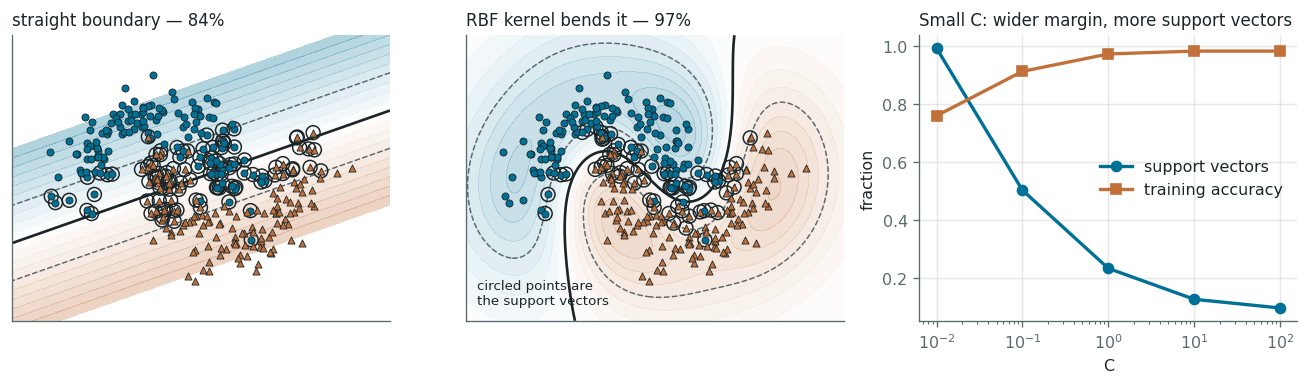

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))


def draw_boundary(ax, model, X, y, title):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 200),
                         np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, 200))
    scores = svm_score(np.c_[xx.ravel(), yy.ravel()], model).reshape(xx.shape)
    ax.contourf(xx, yy, scores, levels=np.linspace(-2.5, 2.5, 21), cmap=CMAP2, alpha=0.32)
    ax.contour(xx, yy, scores, levels=[-1, 0, 1], colors=[GREY, INK, GREY],
               linestyles=["--", "-", "--"], linewidths=[0.9, 1.6, 0.9])
    for label, colour, marker in [(0, BLUE, "o"), (1, ORANGE, "^")]:
        keep = y == label
        ax.scatter(X[keep, 0], X[keep, 1], s=18, color=colour, marker=marker,
                   edgecolor=INK, lw=0.5, zorder=3)
    ax.scatter(model["support_X"][:, 0], model["support_X"][:, 1], s=70,
               facecolors="none", edgecolors=INK, lw=0.9, zorder=2)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)


linear_model = fit_svm(X_moons, y_moons, C=1.0, kind="linear")
rbf_model = fit_svm(X_moons, y_moons, C=1.0, kind="rbf")
linear_acc = (predict_svm(X_moons, linear_model) == y_moons).mean()
rbf_acc = (predict_svm(X_moons, rbf_model) == y_moons).mean()

draw_boundary(axes[0], linear_model, X_moons, y_moons,
              f"straight boundary — {linear_acc:.0%}")
draw_boundary(axes[1], rbf_model, X_moons, y_moons,
              f"RBF kernel bends it — {rbf_acc:.0%}")
axes[1].annotate("circled points are\nthe support vectors", (0.03, 0.06),
                 xycoords="axes fraction", fontsize=8, color=INK)

# what C does: it is the knob for how much the margin may be violated
Cs = [0.01, 0.1, 1.0, 10.0, 100.0]
fraction_support, accuracies = [], []
for c in Cs:
    m = fit_svm(X_moons, y_moons, C=c, kind="rbf")
    fraction_support.append(m["n_support"] / len(X_moons))
    accuracies.append((predict_svm(X_moons, m) == y_moons).mean())
axes[2].plot(Cs, fraction_support, color=BLUE, marker="o", label="support vectors")
axes[2].plot(Cs, accuracies, color=ORANGE, marker="s", label="training accuracy")
axes[2].set_xscale("log")
axes[2].set_xlabel("C"); axes[2].set_ylabel("fraction")
axes[2].set_title("Small C: wider margin, more support vectors")
axes[2].legend(loc="center right"); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---

# Summary

In [19]:
print(f"{'CHECK':<46} {'MINE':>14}   REFERENCE")
print("-" * 90)
for name, mine, reference, ok in RESULTS:
    print(f"{name:<46} {mine:>14}   {reference:<32} {'PASS' if ok else 'FAIL'}")
print("-" * 90)
print(f"{sum(ok for _, _, _, ok in RESULTS)} of {len(RESULTS)} checks passed")

CHECK                                                    MINE   REFERENCE
------------------------------------------------------------------------------------------
linear: coefficients vs sklearn                      1.38e-12   0 (want <1e-8)                   PASS
ridge: coefficients vs sklearn                       5.33e-13   0 (want <1e-8)                   PASS
linear: gradient descent vs direct solve             1.91e-07   0 (want <1e-3)                   PASS
linear: test R^2                                     0.359409   0.359409                         PASS
logistic: coefficients vs sklearn                    7.65e-07   0 (want <1e-4)                   PASS
logistic: test accuracy                              0.958042   0.958042                         PASS
logistic: loss always goes down                          True   True                             PASS
pca: variance ratios vs sklearn                      0.00e+00   0 (want <1e-10)                  PASS
pca: components vs 

---

## Things worth being able to explain

1. Why linear regression has a direct solution and logistic regression does not.
2. What ridge actually does to the coefficients, and why the intercept is left out of it.
3. Why Newton's method needs so few steps, and what it costs per step.
4. Why the eigenvalue of the covariance matrix *is* the variance along that direction.
5. Why softmax and cross-entropy are always used together.
6. Why a gradient check can fail even when the gradient is correct (see the step-size plot).
7. Why the SVM dual lets you swap in a kernel but the primal does not.
8. Why SMO has to update two multipliers at once instead of one.